# **K Nearest Neighbour(KNN)**

Using KNN Algorithm for a dataset

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df_id = '17cbDNBmys04MJqQfrma3jd72VPMnxIq0'
df_url = f'https://drive.google.com/uc?export=download&id={df_id}'
df = pd.read_csv(df_url)
df.head()


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [43]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    df.loc[:, df.columns != "Type"],
    df["Type"],
    test_size=0.2,
    random_state=42,
)

In [44]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

The optimal k value is: 3 (with an accuracy of 0.8140)


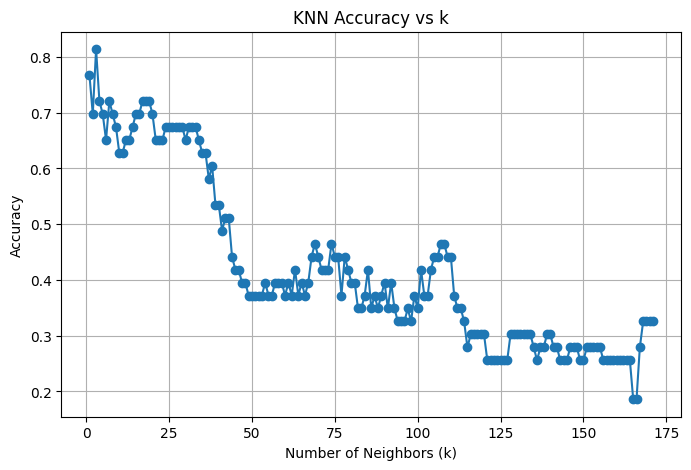

In [45]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


scores = []
k_values = range(1, len(X_train) + 1)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    scores.append(accuracy_score(y_test, pred))
maxi_index = np.argmax(scores)
print(f"The optimal k value is: {k_values[maxi_index]} (with an accuracy of {scores[maxi_index]:.4f})")

plt.figure(figsize=(8, 5))
plt.plot(k_values, scores, marker='o')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs k")
plt.grid(True)
plt.show()

In [46]:
knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train,y_train)
pred=knn.predict(X_test)
print(accuracy_score(y_test,pred))

0.813953488372093
